<a href="https://colab.research.google.com/github/gustavo159753/Analise-de-dados/blob/main/topsis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Estruturar Entrada de Dados Única

In [65]:
import numpy as np

# --- PAINEL DE CONTROLE DE DADOS (TOPSIS) ---

# 1. Nomes das Alternativas
elementos = ['Ciclone1', 'Ciclone2', 'Ciclone3', 'Ciclone4', 'Ciclone5']

# 2. Nomes dos Criterios
criterios = [
    'Eficiencia(%)',
    'Preco (R$)',
    'Validade (anos)',
    'Material (nota)',
    'Manutencao (x/ano)',
    'Frete (R$)',
    'Avaliacoes'
]

# 3. Matriz de Dados (Listas de valores para cada alternativa)
dados_alternativas = [
    [72, 85000, 20, 8, 1, 1800, 5], # Ciclone1
    [80, 150000, 15, 8, 1, 3000, 7], # Ciclone2
    [92, 180000, 30, 9, 2, 2500, 9], # Ciclone3
    [55, 110000, 5, 6, 5, 500, 6],   # Ciclone4
    [85, 200000, 10, 9.5, 1, 1000, 8] # Ciclone5 (Corrigido: adicionado valor de manutenção)
]

# 4. Pesos de Importancia Relativa
pesos_criterios = [0.1, 0.3, 0.1, 0.05, 0.05, 0.3, 0.1]

# 5. Classificacao dos Criterios ('beneficio' ou 'custo')
tipos_criterios = ['beneficio', 'custo', 'beneficio', 'beneficio', 'custo', 'custo', 'beneficio']

# --- Resumo da Configuracao ---
print('--- Resumo da Entrada de Dados ---')
print(f'Alternativas ({len(elementos)}): {elementos}')
print(f'Criterios ({len(criterios)}): {criterios}')
print(f'Pesos definidos: {pesos_criterios}')
print(f'Tipos de criterios: {tipos_criterios}')
print('----------------------------------')

--- Resumo da Entrada de Dados ---
Alternativas (5): ['Ciclone1', 'Ciclone2', 'Ciclone3', 'Ciclone4', 'Ciclone5']
Criterios (7): ['Eficiencia(%)', 'Preco (R$)', 'Validade (anos)', 'Material (nota)', 'Manutencao (x/ano)', 'Frete (R$)', 'Avaliacoes']
Pesos definidos: [0.1, 0.3, 0.1, 0.05, 0.05, 0.3, 0.1]
Tipos de criterios: ['beneficio', 'custo', 'beneficio', 'beneficio', 'custo', 'custo', 'beneficio']
----------------------------------


## Automatizar Processamento de Matriz

In [66]:
import numpy as np

# 1. Converter a lista dados_alternativas em um array NumPy chamado matriz_d (float)
matriz_d = np.array(dados_alternativas, dtype=float)

# 2. Verificacao de dimensoes
n_alternativas = len(elementos)
n_criterios = len(criterios)
linhas, colunas = matriz_d.shape

print("--- Validacao da Matriz de Decisao ---")
print(f"Matriz D (Conteudo):\n{matriz_d}")
print(f"\nDimensao da Matriz: {linhas} linhas x {colunas} colunas")

# 3. Validacao Logica
if linhas == n_alternativas and colunas == n_criterios:
    print("\n[SUCESSO] As dimensoes da matriz estao corretas e correspondem aos inputs.")
else:
    print(f"\n[ERRO] Inconsistencia detectada!")
    print(f"Esperado: {n_alternativas} alternativas, {n_criterios} criterios.")
    print(f"Encontrado na matriz: {linhas} alternativas, {colunas} criterios.")

--- Validacao da Matriz de Decisao ---
Matriz D (Conteudo):
[[7.2e+01 8.5e+04 2.0e+01 8.0e+00 1.0e+00 1.8e+03 5.0e+00]
 [8.0e+01 1.5e+05 1.5e+01 8.0e+00 1.0e+00 3.0e+03 7.0e+00]
 [9.2e+01 1.8e+05 3.0e+01 9.0e+00 2.0e+00 2.5e+03 9.0e+00]
 [5.5e+01 1.1e+05 5.0e+00 6.0e+00 5.0e+00 5.0e+02 6.0e+00]
 [8.5e+01 2.0e+05 1.0e+01 9.5e+00 1.0e+00 1.0e+03 8.0e+00]]

Dimensao da Matriz: 5 linhas x 7 colunas

[SUCESSO] As dimensoes da matriz estao corretas e correspondem aos inputs.


## Executar Motor TOPSIS e Gerar Tabelas


In [67]:
import pandas as pd

# --- EXECUTANDO O MOTOR TOPSIS ---

final_ranking_df = perform_topsis(
    elements=elementos,
    raw_alternatives_data=matriz_d,
    weights=pesos_criterios,
    criterion_types=tipos_criterios,
    metric='L2'
)

# --- EXIBINDO DOS RESULTADOS ---

print("--- RESULTADO FINAL DO RANKING TOPSIS ---")
display(final_ranking_df.style.highlight_max(subset=['Ksi (C_i)'], color='lightgreen').format({'di+': '{:.4f}', 'di-': '{:.4f}', 'Ksi (C_i)': '{:.4f}'}))

melhor_opcao = final_ranking_df.iloc[0]['Alternativa']
print(f"\nA melhor alternativa selecionada é: {melhor_opcao}")

--- RESULTADO FINAL DO RANKING TOPSIS ---


,Alternativa,di+,di-,Ksi (C_i)
3,Ciclone4,0.0802,0.1869,0.6998
0,Ciclone1,0.0953,0.1404,0.5957
4,Ciclone5,0.1185,0.1428,0.5464
2,Ciclone3,0.1595,0.0842,0.3456
1,Ciclone2,0.1828,0.0650,0.2622



A melhor alternativa selecionada é: Ciclone4


## Gerar Relatório de Sensibilidade e Robustez


Resultados da Analise de Sensibilidade (Score Ksi):


,Base,Foco Eficiencia,Foco Custo,Equilibrado,Foco Manutencao
Ciclone1,0.595676,0.947873,0.928328,0.812740,0.976355
Ciclone2,0.262186,0.928615,0.873046,0.736492,0.964851
Ciclone3,0.345605,0.745231,0.729968,0.670921,0.748783
Ciclone4,0.699784,0.068825,0.128331,0.255756,0.034171
Ciclone5,0.546449,0.962230,0.937841,0.807078,0.975666


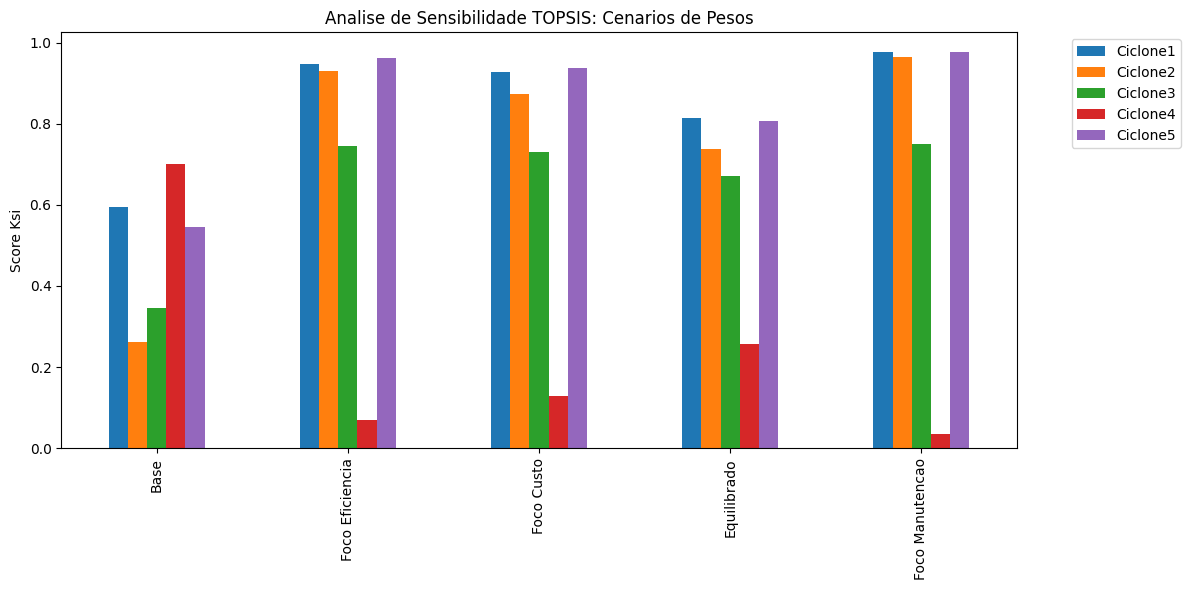

In [68]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Recalcular Matriz Normalizada para os novos dados
norma = np.linalg.norm(matriz_d, axis=0)
matriz_normalizada = np.divide(matriz_d, norma, out=np.zeros_like(matriz_d), where=norma!=0)

# 2. Helper de Cenários
def run_topsis_scenario(weights):
    matrix_r = matriz_normalizada * weights
    a_plus = []
    a_minus = []
    for j in range(matrix_r.shape[1]):
        column = matrix_r[:, j]
        if tipos_criterios[j] == 'beneficio':
            a_plus.append(np.max(column))
            a_minus.append(np.min(column))
        else:
            a_plus.append(np.min(column))
            a_minus.append(np.max(column))
    a_plus, a_minus = np.array(a_plus), np.array(a_minus)
    dist_p = np.sqrt(np.sum((matrix_r - a_plus)**2, axis=1))
    dist_m = np.sqrt(np.sum((matrix_r - a_minus)**2, axis=1))
    return dist_m / (dist_p + dist_m)

# 3. Cenários
scenarios = {
    'Base': pesos_criterios,
    'Foco Eficiencia': [0.25, 0.10, 0.05, 0.10, 1.7, 0.15, 0.15],
    'Foco Custo': [0.10, 0.20, 0.05, 0.10, 1.7, 0.30, 0.10],
    'Equilibrado': [0.2, 0.2, 0.1, 0.1, 0.5, 0.2, 0.2],
    'Foco Manutencao': [0.1, 0.1, 0.05, 0.1, 2.5, 0.1, 0.1]
}

# 4. Execução e Plot
results = {name: run_topsis_scenario(w) for name, w in scenarios.items()}
sensitivity_df = pd.DataFrame(results, index=elementos)

print("Resultados da Analise de Sensibilidade (Score Ksi):")
display(sensitivity_df)

sensitivity_df.T.plot(kind='bar', figsize=(12, 6))
plt.title('Analise de Sensibilidade TOPSIS: Cenarios de Pesos')
plt.ylabel('Score Ksi')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Comparativo de Multiplas Metricas de Distancia:


,Euclidiana (L2),Manhattan (L1),Minkowski (p=3),Chebyshev (L-inf)
Ciclone1,0.595676,0.638776,0.571996,0.537661
Ciclone2,0.262186,0.322683,0.237054,0.208184
Ciclone3,0.345605,0.458101,0.320566,0.313066
Ciclone4,0.699784,0.601809,0.721638,0.732818
Ciclone5,0.546449,0.538862,0.560083,0.569510


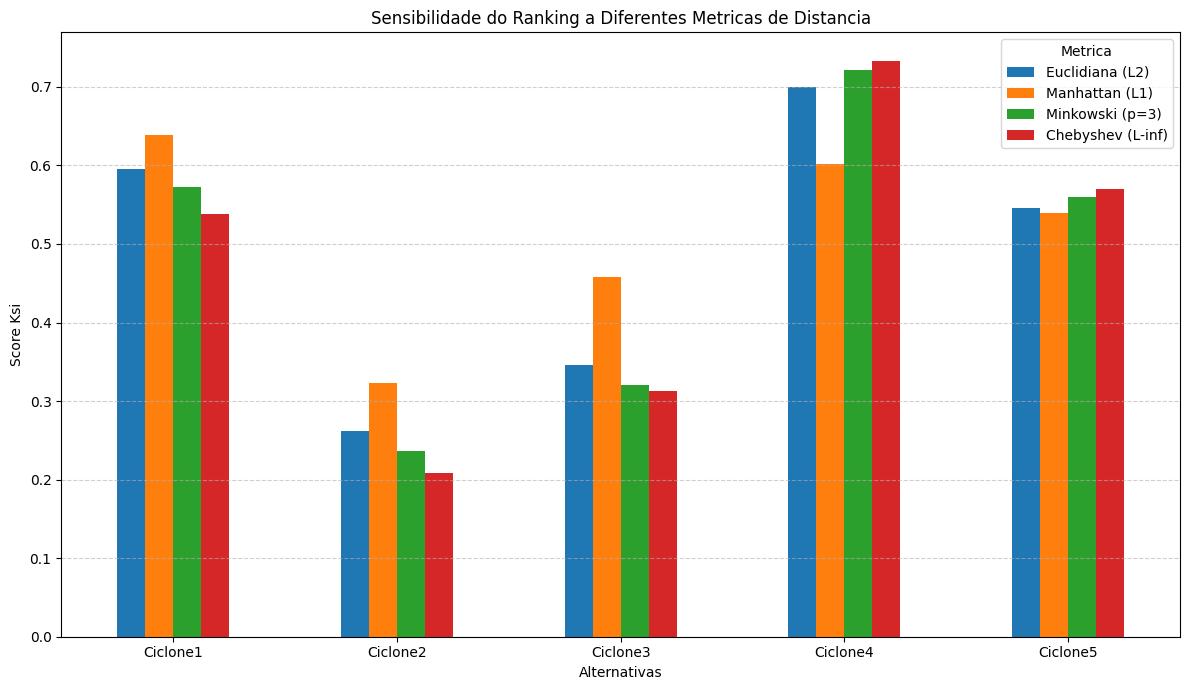

In [69]:
def run_topsis_metrics(weights, metric='L2', p_val=3):
    matrix_r = matriz_normalizada * weights
    a_plus = []
    a_minus = []
    for j in range(matrix_r.shape[1]):
        column = matrix_r[:, j]
        if tipos_criterios[j] == 'beneficio':
            a_plus.append(np.max(column))
            a_minus.append(np.min(column))
        else:
            a_plus.append(np.min(column))
            a_minus.append(np.max(column))
    a_plus, a_minus = np.array(a_plus), np.array(a_minus)

    if metric == 'L2':
        dist_p = np.sqrt(np.sum((matrix_r - a_plus)**2, axis=1))
        dist_m = np.sqrt(np.sum((matrix_r - a_minus)**2, axis=1))
    elif metric == 'L1':
        dist_p = np.sum(np.abs(matrix_r - a_plus), axis=1)
        dist_m = np.sum(np.abs(matrix_r - a_minus), axis=1)
    elif metric == 'Minkowski':
        dist_p = np.sum(np.abs(matrix_r - a_plus)**p_val, axis=1)**(1/p_val)
        dist_m = np.sum(np.abs(matrix_r - a_minus)**p_val, axis=1)**(1/p_val)
    elif metric == 'Chebyshev':
        dist_p = np.max(np.abs(matrix_r - a_plus), axis=1)
        dist_m = np.max(np.abs(matrix_r - a_minus), axis=1)

    return dist_m / (dist_p + dist_m)

metrics_results = {
    'Euclidiana (L2)': run_topsis_metrics(pesos_criterios, metric='L2'),
    'Manhattan (L1)': run_topsis_metrics(pesos_criterios, metric='L1'),
    'Minkowski (p=3)': run_topsis_metrics(pesos_criterios, metric='Minkowski'),
    'Chebyshev (L-inf)': run_topsis_metrics(pesos_criterios, metric='Chebyshev')
}

comparison_metrics_df = pd.DataFrame(metrics_results, index=elementos)
print('Comparativo de Multiplas Metricas de Distancia:')
display(comparison_metrics_df)

comparison_metrics_df.plot(kind='bar', figsize=(12, 7))
plt.title('Sensibilidade do Ranking a Diferentes Metricas de Distancia')
plt.xlabel('Alternativas')
plt.ylabel('Score Ksi')
plt.xticks(rotation=0)
plt.legend(title='Metrica', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

--- RESULTADO DA ANÁLISE DE ROBUSTEZ ---
Frequência de 1º Lugar em 10000 simulações:
Ciclone1    31.57
Ciclone2     2.55
Ciclone3     4.72
Ciclone4    46.18
Ciclone5    14.98
Name: proportion, dtype: float64


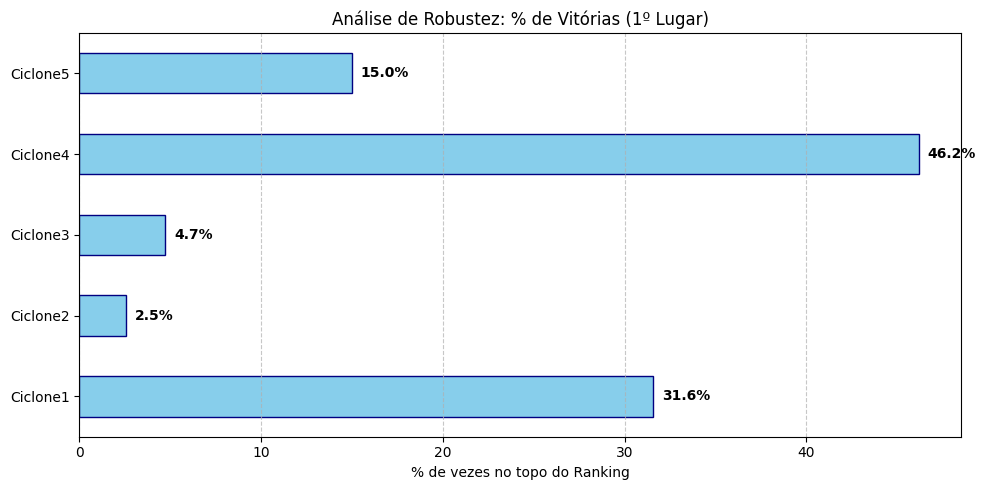

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Parâmetros da simulação
np.random.seed(42)
n_simulations = 10000
noise_std = 0.2
winners = []

# 2. Execução da Simulação
for _ in range(n_simulations):
    noise = np.random.normal(0, noise_std, matriz_normalizada.shape)
    perturbed_matrix = np.clip(matriz_normalizada + noise, 0, 1)
    # Usamos a lógica de cálculo baseada nos pesos originais
    matrix_r = perturbed_matrix * pesos_criterios
    a_plus = []
    a_minus = []
    for j in range(matrix_r.shape[1]):
        col = matrix_r[:, j]
        if tipos_criterios[j] == 'beneficio':
            a_plus.append(np.max(col))
            a_minus.append(np.min(col))
        else:
            a_plus.append(np.min(col))
            a_minus.append(np.max(col))
    a_p, a_m = np.array(a_plus), np.array(a_minus)
    dist_p = np.sqrt(np.sum((matrix_r - a_p)**2, axis=1))
    dist_m = np.sqrt(np.sum((matrix_r - a_m)**2, axis=1))
    scores = dist_m / (dist_p + dist_m)
    winners.append(elementos[np.argmax(scores)])

# 3. Processamento de Resultados
win_counts = pd.Series(winners).value_counts(normalize=True) * 100
win_counts = win_counts.reindex(elementos, fill_value=0.0)

print("--- RESULTADO DA ANÁLISE DE ROBUSTEZ ---")
print(f"Frequência de 1º Lugar em {n_simulations} simulações:")
print(win_counts)

# 4. Gráfico formatado
plt.figure(figsize=(10, 5))
ax = win_counts.plot(kind='barh', color='skyblue', edgecolor='navy')
plt.title('Análise de Robustez: % de Vitórias (1º Lugar)')
plt.xlabel('% de vezes no topo do Ranking')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionar rótulos de porcentagem nas barras
for i, v in enumerate(win_counts):
    ax.text(v + 0.5, i, f'{v:.1f}%', color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()